In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [5]:
date_range=pd.date_range(start='2014-03-17' , end='2026-02-09', freq='ME')
np.random.seed(42)
data= pd.DataFrame({
    'Date': date_range,
    'Sales' : np.random.randint(200,500,size=len(date_range))
})
data.set_index('Date', inplace= True)
print(data.head())

            Sales
Date             
2014-03-31    302
2014-04-30    470
2014-05-31    306
2014-06-30    271
2014-07-31    388


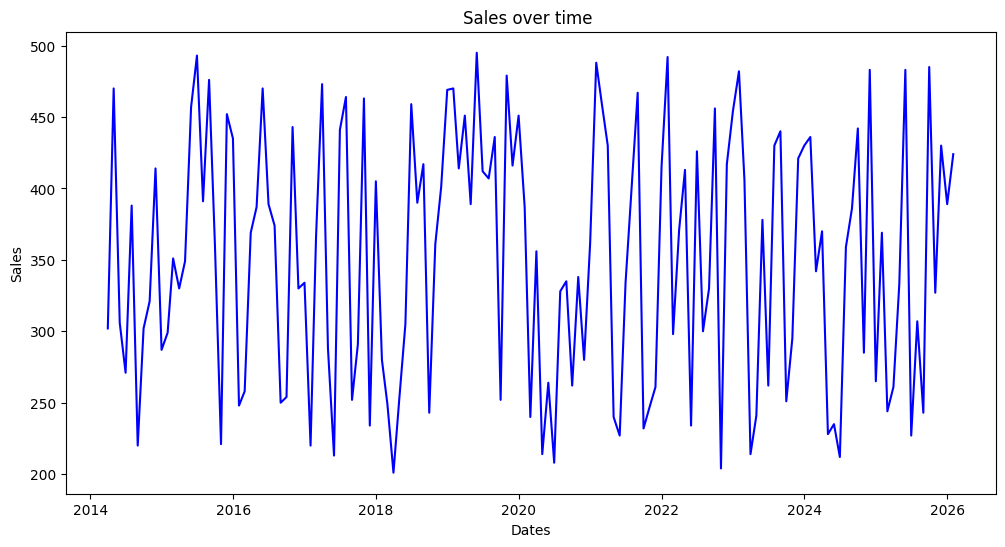

In [7]:
plt.figure(figsize=(12,6))
plt.plot(data.index,data['Sales'],color='Blue')
plt.title("Sales over time ")
plt.xlabel("Dates")
plt.ylabel("Sales")
plt.show()


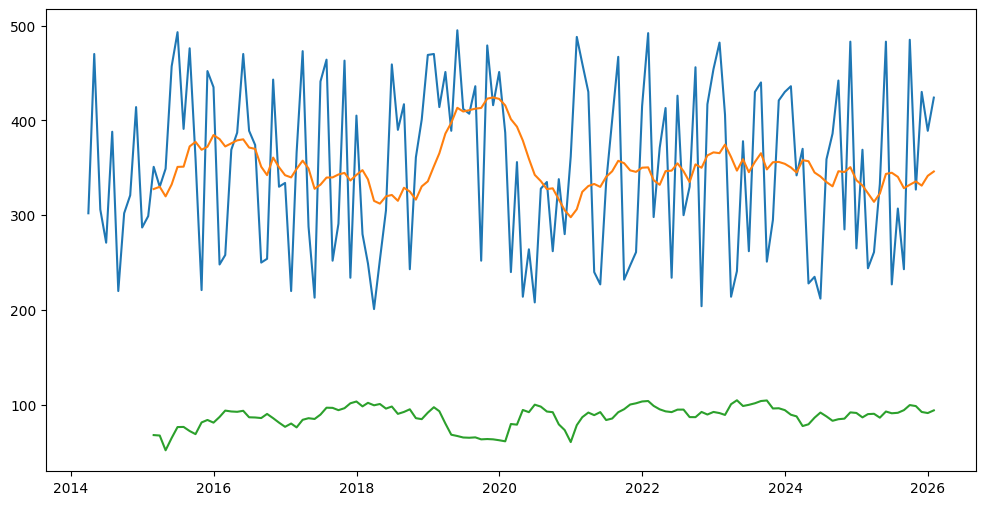

In [8]:
rolling_mean=data['Sales'].rolling(window=12).mean()
rolling_std=data['Sales'].rolling(window=12).std()
plt.figure(figsize=(12,6))
plt.plot(data['Sales'], label='original')
plt.plot(rolling_mean, label='rolling mean')
plt.plot(rolling_std, label='rolling std')
plt.show()

In [13]:
!pip install statsmodels

   ---------------------------------------- 0.0/9.5 MB ? eta -:--:--
   - -------------------------------------- 0.3/9.5 MB ? eta -:--:--
   -- ------------------------------------- 0.5/9.5 MB 1.6 MB/s eta 0:00:06
   --- ------------------------------------ 0.8/9.5 MB 1.5 MB/s eta 0:00:06
   ---- ----------------------------------- 1.0/9.5 MB 1.5 MB/s eta 0:00:06
   ----- ---------------------------------- 1.3/9.5 MB 1.4 MB/s eta 0:00:06
   ------- -------------------------------- 1.8/9.5 MB 1.5 MB/s eta 0:00:06
   -------- ------------------------------- 2.1/9.5 MB 1.5 MB/s eta 0:00:05
   ---------- ----------------------------- 2.6/9.5 MB 1.6 MB/s eta 0:00:05
   ------------ --------------------------- 2.9/9.5 MB 1.6 MB/s eta 0:00:05
   -------------- ------------------------- 3.4/9.5 MB 1.6 MB/s eta 0:00:04
   --------------- ------------------------ 3.7/9.5 MB 1.6 MB/s eta 0:00:04
   ----------------- ---------------------- 4.2/9.5 MB 1.6 MB/s eta 0:00:04
   ------------------ ----


[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


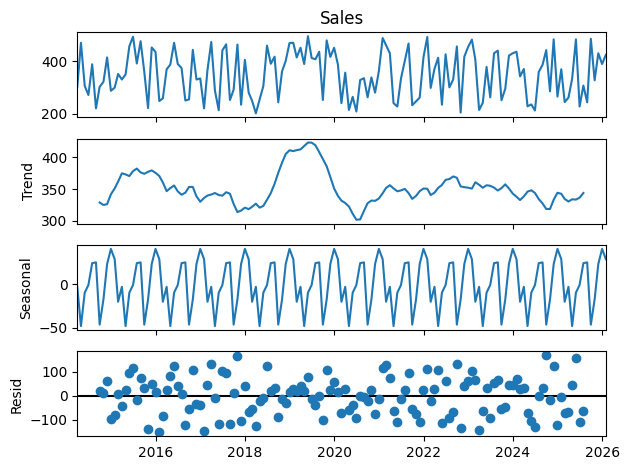

In [14]:
from statsmodels.tsa.seasonal import seasonal_decompose
decomposition=seasonal_decompose(data['Sales'],model='Additive')
decomposition.plot()
plt.show()

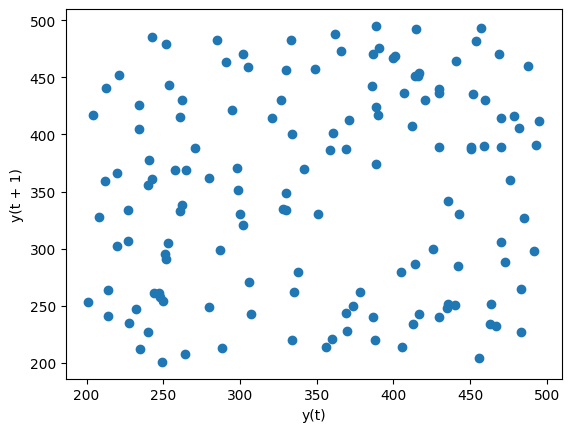

In [15]:
from pandas.plotting import lag_plot
lag_plot(data['Sales'])
plt.show()

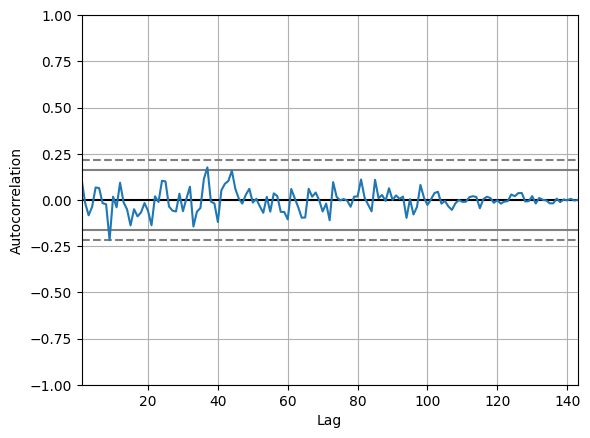

In [17]:
from pandas.plotting import autocorrelation_plot
autocorrelation_plot(data['Sales'])
plt.show()

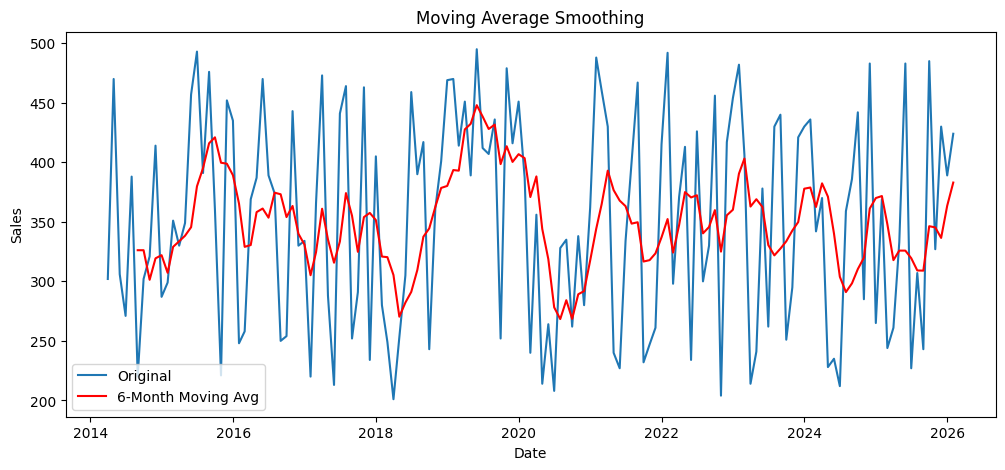

In [18]:
import matplotlib.pyplot as plt

# Calculate 6-month moving average
data['MA_6'] = data['Sales'].rolling(window=6).mean()

# Plot
plt.figure(figsize=(12, 5))

plt.plot(data['Sales'], label='Original')
plt.plot(data['MA_6'], label='6-Month Moving Avg', color='red')

plt.legend()
plt.title("Moving Average Smoothing")
plt.xlabel("Date")
plt.ylabel("Sales")

plt.show()

In [19]:
data['Month']=data.index.month
data['Year']=data.index.year
data

,Sales,MA_6,Month,Year
Date,,,,
2014-03-31,302,NaN,3,2014
2014-04-30,470,NaN,4,2014
2014-05-31,306,NaN,5,2014
2014-06-30,271,NaN,6,2014
2014-07-31,388,NaN,7,2014
...,...,...,...,...
2025-09-30,485,346.333333,9,2025
2025-10-31,327,345.333333,10,2025
2025-11-30,430,336.500000,11,2025


In [20]:
monthly_avg= data.groupby('Month')['Sales'].mean()

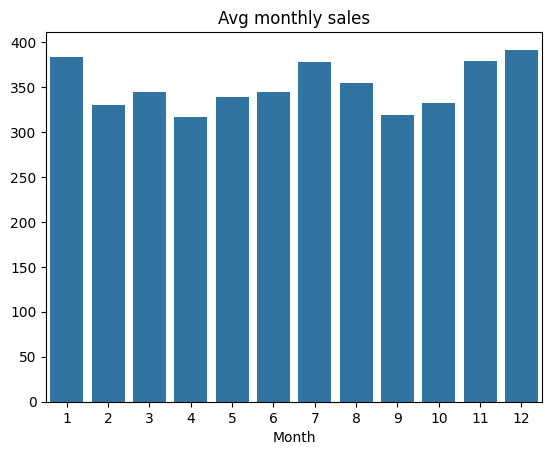

In [21]:
sns.barplot(x=monthly_avg.index, y=monthly_avg.values)
plt.title("Avg monthly sales")
plt.show()

In [22]:
pivot= data.pivot_table(values='Sales', index='Year', columns='Month')
pivot

Month,1,2,3,4,5,6,7,8,9,10,11,12
Year,,,,,,,,,,,,
2014,NaN,NaN,302.0,470.0,306.0,271.0,388.0,220.0,302.0,321.0,414.0,287.0
2015,299.0,351.0,330.0,349.0,457.0,493.0,391.0,476.0,360.0,221.0,452.0,435.0
2016,248.0,258.0,369.0,387.0,470.0,389.0,374.0,250.0,254.0,443.0,330.0,334.0
2017,220.0,366.0,473.0,288.0,213.0,441.0,464.0,252.0,291.0,463.0,234.0,405.0
2018,280.0,249.0,201.0,253.0,305.0,459.0,390.0,417.0,243.0,361.0,401.0,469.0
2019,470.0,414.0,451.0,389.0,495.0,412.0,407.0,436.0,252.0,479.0,416.0,451.0
2020,387.0,240.0,356.0,214.0,264.0,208.0,328.0,335.0,262.0,338.0,280.0,362.0
2021,488.0,460.0,430.0,240.0,227.0,334.0,400.0,467.0,232.0,247.0,261.0,415.0
2022,492.0,298.0,371.0,413.0,234.0,426.0,300.0,330.0,456.0,204.0,417.0,454.0


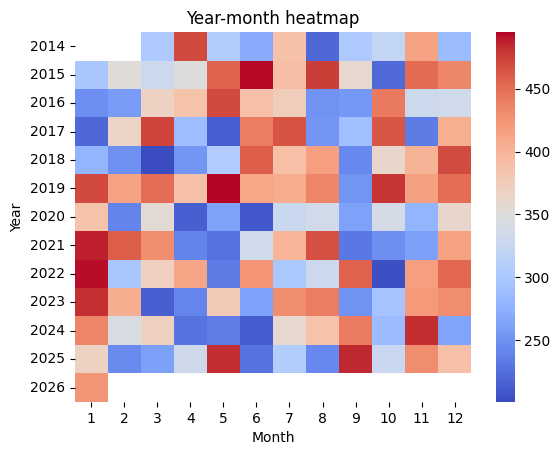

In [23]:
sns.heatmap(pivot, cmap='coolwarm')
plt.title("Year-month heatmap")
plt.show()